**Imports, Chargement et Feature Engineering Clinique**

In [3]:
import os
import sys
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

if '..' not in sys.path:
    sys.path.append('..')

from src.preprocessing import create_clinical_features, build_preprocessing_pipeline

df_raw = pd.read_csv("../data/raw/alzheimer_clinical.csv")
df = create_clinical_features(df_raw)

# Encodage de la variable cible
target_map = {'CN': 0, 'MCI': 1, 'AD': 2}
y = df['Label'].map(target_map).values
X = df.drop(columns=['Label', 'Subject_ID'], errors='ignore')

# Split 80/20 Stratifié de production
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Données prêtes pour l'entraînement !")
print(f"Train set : {X_train.shape} | Test set : {X_test.shape}")
print(f"Répartition des classes dans le Train : {np.bincount(y_train)} (CN, MCI, AD)")

Données prêtes pour l'entraînement !
Train set : (1200, 23) | Test set : (300, 23)
Répartition des classes dans le Train : [540 420 240] (CN, MCI, AD)


**Évaluation des Modèles Candidats par Cross-Validation**

In [5]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold, cross_validate
from src.models import get_candidate_models

# Définition des listes de features pour le ColumnTransformer
NUMERICAL_FEATURES = [
    'Age', 'Education', 'MMSE', 'nWBV', 'eTIV', 'ASF',
    'Abeta42', 'pTau181', 'NfL', 'FAQ', 'APOE4',
    'Amyloid_Tau_Ratio', 'Cog_Functional_Score', 'Brain_Age_Ratio',
    'APOE4_Risk', 'Comorbidity_Index', 'NfL_Age_Adjusted'
]
CATEGORICAL_FEATURES = ['Sex', 'Hypertension', 'Diabetes', 'Depression_Hx']

# Instanciation du préprocesseur
preprocessor = build_preprocessing_pipeline(NUMERICAL_FEATURES, CATEGORICAL_FEATURES)

# Calcul des poids de compensation
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)

# Récupération des modèles
models = get_candidate_models(preprocessor, class_weights)

# Lancement de la cross-validation rigoureuse
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print("Évaluation des modèles en cours (Cross-Validation 5-Fold)...")
for name, pipeline in models.items():
    scores = cross_validate(
        pipeline, X_train, y_train, cv=cv,
        scoring={'f1_macro': 'f1_macro', 'f1_weighted': 'f1_weighted', 'accuracy': 'accuracy', 'roc_auc_ovr': 'roc_auc_ovr_weighted'},
        n_jobs=-1, return_train_score=True
    )
    results[name] = {
        'F1_Macro (CV)': f"{scores['test_f1_macro'].mean():.4f} ± {scores['test_f1_macro'].std():.4f}",
        'F1_Weighted (CV)': f"{scores['test_f1_weighted'].mean():.4f}",
        'ROC_AUC (CV)': f"{scores['test_roc_auc_ovr'].mean():.4f}",
        'Overfitting Gap': f"{(scores['train_f1_macro'].mean() - scores['test_f1_macro'].mean()):.4f}"
    }

results_df = pd.DataFrame(results).T
print("\n TABLEAU COMPARATIF DES PERFORMANCES :")
print(results_df.sort_values('F1_Macro (CV)', ascending=False))

Évaluation des modèles en cours (Cross-Validation 5-Fold)...

 TABLEAU COMPARATIF DES PERFORMANCES :
                       F1_Macro (CV) F1_Weighted (CV) ROC_AUC (CV)  \
CatBoost             0.9943 ± 0.0048           0.9933       0.9993   
Random_Forest        0.9918 ± 0.0057           0.9908       0.9994   
XGBoost              0.9904 ± 0.0078           0.9900       0.9986   
Logistic_Regression  0.9904 ± 0.0057           0.9892       0.9996   
LightGBM             0.9872 ± 0.0100           0.9858       0.9991   

                    Overfitting Gap  
CatBoost                     0.0057  
Random_Forest                0.0082  
XGBoost                      0.0096  
Logistic_Regression          0.0043  
LightGBM                     0.0128  


**Optimisation Optuna (hyperparameter tuning de production)**

In [7]:
# ── CELLULE 3 : OPTIMISATION PAR ALGORITHME BAYÉSIEN (OPTUNA) ──
import optuna
from optuna.samplers import TPESampler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from lightgbm import LGBMClassifier

# Désactiver les logs denses d'Optuna pour garder un affichage propre
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Redéfinition locale des listes de features épurées pour sécurité
NUMERICAL_FEATURES_CLEAN = [
    'Age', 'Education', 'MMSE', 'nWBV', 'eTIV', 'ASF',
    'Abeta42', 'pTau181', 'NfL', 'FAQ', 'APOE4',
    'Amyloid_Tau_Ratio', 'Cog_Functional_Score', 'Brain_Age_Ratio',
    'APOE4_Risk', 'Comorbidity_Index', 'NfL_Age_Adjusted'
]
CATEGORICAL_FEATURES_CLEAN = ['Sex', 'Hypertension', 'Diabetes', 'Depression_Hx']

def objective_lgbm(trial):
    """Fonction objectif Optuna optimisant le pipeline complet LightGBM."""
    params = {
        'clf__n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'clf__max_depth':         trial.suggest_int('max_depth', 3, 8),
        'clf__learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'clf__num_leaves':        trial.suggest_int('num_leaves', 15, 63),
        'clf__min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'clf__subsample':         trial.suggest_float('subsample', 0.7, 1.0),
        'clf__colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'clf__reg_alpha':         trial.suggest_float('reg_alpha', 1e-5, 1.0, log=True),
        'clf__reg_lambda':        trial.suggest_float('reg_lambda', 1e-5, 1.0, log=True),
    }
    
    # Reconstruction dynamique du pipeline de production
    pipeline = Pipeline([
        ('preprocessor', build_preprocessing_pipeline(
            NUMERICAL_FEATURES_CLEAN, CATEGORICAL_FEATURES_CLEAN
        )),
        ('clf', LGBMClassifier(
            objective='multiclass', num_class=3,
            class_weight='balanced', random_state=42,
            n_jobs=-1, verbose=-1
        ))
    ])
    
    # Injection des paramètres suggérés par l'algorithme bayésien
    pipeline.set_params(**params)
    
    # Évaluation robuste par cross-validation à 5 plis
    score = cross_val_score(
        pipeline, X_train, y_train,
        cv=StratifiedKFold(5, shuffle=True, random_state=42),
        scoring='f1_macro',
        n_jobs=-1
    ).mean()
    
    return score

# Initialisation de l'étude bayésienne avec notre graine aléatoire fixe
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))

print(" Recherche intelligente des meilleurs hyperparamètres (20 essais)...")
study.optimize(objective_lgbm, n_trials=20, timeout=600)

print("\n [OPTIMISATION TERMINÉE]")
print(f"Meilleur score F1-Macro obtenu en CV : {study.best_value:.4f}")
print("Meilleurs hyperparamètres trouvés :")
for key, value in study.best_params.items():
    print(f"  → {key}: {value}")

⏳ Recherche intelligente des meilleurs hyperparamètres (20 essais)...

 [OPTIMISATION TERMINÉE]
Meilleur score F1-Macro obtenu en CV : 0.9944
Meilleurs hyperparamètres trouvés :
  → n_estimators: 462
  → max_depth: 5
  → learning_rate: 0.017074220010682283
  → num_leaves: 37
  → min_child_samples: 36
  → subsample: 0.9583345059151345
  → colsample_bytree: 0.657510456351297
  → reg_alpha: 0.024066257329320922
  → reg_lambda: 4.118431438609294e-05


**Évaluation finale et Matrice de Confusion**

 RAPPORT DE CLASSIFICATION FINAL (SUR LE TEST SET) :
              precision    recall  f1-score   support

          CN       0.96      0.99      0.97       135
         MCI       0.98      0.94      0.96       105
          AD       1.00      1.00      1.00        60

    accuracy                           0.97       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.97      0.97      0.97       300



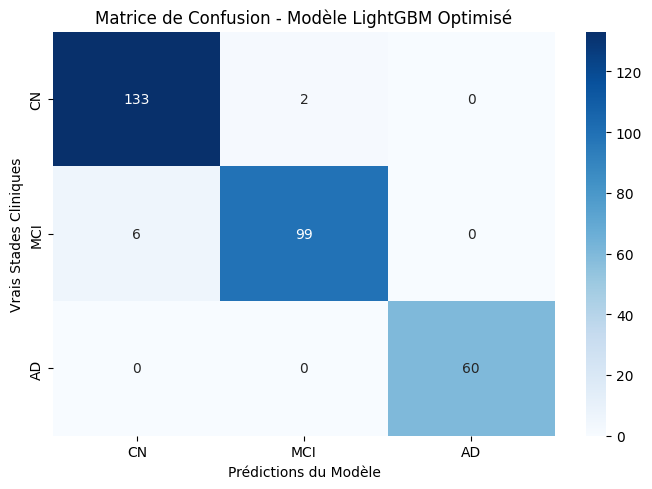

In [10]:
# ── CELLULE 4 : ENTRAÎNEMENT FINAL ET MATRICE DE CONFUSION ──
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Instanciation du modèle champion avec les paramètres optimisés par Optuna
best_params = {f'clf__{k}': v for k, v in study.best_params.items()}

champion_pipeline = Pipeline([
    ('preprocessor', build_preprocessing_pipeline(
        NUMERICAL_FEATURES_CLEAN, CATEGORICAL_FEATURES_CLEAN
    )),
    ('clf', LGBMClassifier(
        objective='multiclass', num_class=3,
        class_weight='balanced', random_state=42,
        n_jobs=-1, verbose=-1
    ))
])

# Injection des meilleurs paramètres
champion_pipeline.set_params(**best_params)

# 2. Entraînement final sur l'ensemble du Train Set
champion_pipeline.fit(X_train, y_train)

# 3. Prédiction sur le Test Set (le vrai crash test)
y_pred = champion_pipeline.predict(X_test)

# 4. Affichage du rapport textuel des performances
print(" RAPPORT DE CLASSIFICATION FINAL (SUR LE TEST SET) :")
print(classification_report(y_test, y_pred, target_names=['CN', 'MCI', 'AD']))

# 5. Génération et affichage de la Matrice de Confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['CN', 'MCI', 'AD'],
            yticklabels=['CN', 'MCI', 'AD'])
plt.title('Matrice de Confusion - Modèle LightGBM Optimisé')
plt.xlabel('Prédictions du Modèle')
plt.ylabel('Vrais Stades Cliniques')
plt.tight_layout()
os.makedirs("../reports/figures", exist_ok=True)
plt.savefig("../reports/figures/04_confusion_matrix.png", dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# ── CELLULE D'EXPORTATION DES ARTEFACTS DE PRODUCTION 
import joblib
import os
import shap
import numpy as np

# Création du dossier s'il n'existe pas
os.makedirs("../models", exist_ok=True)

NUMERICAL_FEATURES_CLEAN = [
    'Age', 'Education', 'MMSE', 'nWBV', 'eTIV', 'ASF',
    'Abeta42', 'pTau181', 'NfL', 'FAQ', 'APOE4',
    'Amyloid_Tau_Ratio', 'Cog_Functional_Score', 'Brain_Age_Ratio',
    'APOE4_Risk', 'Comorbidity_Index', 'NfL_Age_Adjusted'
]
CATEGORICAL_FEATURES_CLEAN = ['Sex', 'Hypertension', 'Diabetes', 'Depression_Hx']

# C'est l'ordre exact dans lequel le ColumnTransformer recrache les colonnes après preprocessing
production_feature_names = NUMERICAL_FEATURES_CLEAN + CATEGORICAL_FEATURES_CLEAN

# 1. Sauvegarde du pipeline complet (Préprocesseur + LightGBM champion)
joblib.dump(champion_pipeline, "../models/best_pipeline.pkl")

# 2. Sauvegarde des listes de features nettoyées (avec le bon nom de variable !)
joblib.dump(production_feature_names, "../models/feature_names.pkl")

# 3. Calcul et sauvegarde de l'explainer SHAP de production
X_train_transformed = champion_pipeline.named_steps['preprocessor'].transform(X_train)
lgbm_model = champion_pipeline.named_steps['clf']

production_explainer = shap.TreeExplainer(lgbm_model)
joblib.dump(production_explainer, "../models/shap_explainer.pkl")

print(" [SUCCESS] Tous les artefacts ont été sérialisés avec succès dans /models/ !")
print("  → best_pipeline.pkl")
print("  → feature_names.pkl")
print("  → shap_explainer.pkl")

 [SUCCESS] Tous les artefacts ont été sérialisés avec succès dans /models/ !
  → best_pipeline.pkl
  → feature_names.pkl
  → shap_explainer.pkl
